# Catchment water balance and simulation

Majd Yousof · CIVE70020 Water Resources Engineering · December 2024

This notebook analyses catchment 39008 near Oxford:
water balance, annual precipitation–crop-demand balance, rainfall–runoff calibration,
groundwater comparison and reservoir storage using the Waitt curve.

Open this notebook from the project directory, then **Restart Kernel and Run All Cells**.
Figures are written to `outputs/plots/`. The Nelder–Mead calibration runs in full
and can take several minutes. The supplied model is kept in `model.py`.
The accompanying discussion is in [report.pdf](report/report.pdf).


In [1]:
## importing relevant packages

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from numpy.typing import NDArray
from scipy.optimize import minimize
from scipy.stats import norm

from model import least_squares, objective_function, simulate

In [2]:
## loading the data ##

# Catchment information data
data_dir = Path("data")
plot_dir = Path("outputs/plots")
plot_dir.mkdir(parents=True, exist_ok=True)
catchment_dir = data_dir / "Catchment"

# Align catchment attributes by gauge identifier, independent of CSV row order.
attribute_names = (
    "humaninfluence",
    "hydrogeology",
    "hydrologic",
    "hydrometry",
    "landcover",
    "soil",
    "topographic",
)
catchment_tables = [
    pd.read_csv(catchment_dir / f"CAMELS_GB_{name}_attributes.csv", index_col="gauge_id")
    for name in attribute_names
]
if any(not table.index.is_unique for table in catchment_tables):
    raise ValueError("Catchment tables must contain unique gauge identifiers.")
catchment = pd.concat(catchment_tables, axis=1, verify_integrity=True)

# Hydrological data
hydrology_dir = data_dir / "Hydrology"
hydrometeorology = pd.read_csv(
    hydrology_dir / "CAMELS_GB_hydromet_timeseries_39008_19701001-20150930.csv"
)
soil_moisture = pd.read_csv(hydrology_dir / "COSMOS_soil_moisture.csv")
# The groundwater CSV has seven metadata rows before its column headings.
groundwater_data = pd.read_csv(hydrology_dir / "GroundwaterData.csv", skiprows=7)

hydrometeorology["date"] = pd.to_datetime(hydrometeorology["date"])
hydrometeorology = hydrometeorology.set_index("date")

# shapefile data
shapefile_dir = catchment_dir / "shapefiles"
catchment_boundary = gpd.read_file(shapefile_dir / "39008_boundary/39008.shp").to_crs("EPSG:4326")
gb_boundary = gpd.read_file(shapefile_dir / "gb/CTRY_DEC_2021_UK_BUC.shp").to_crs("EPSG:4326")

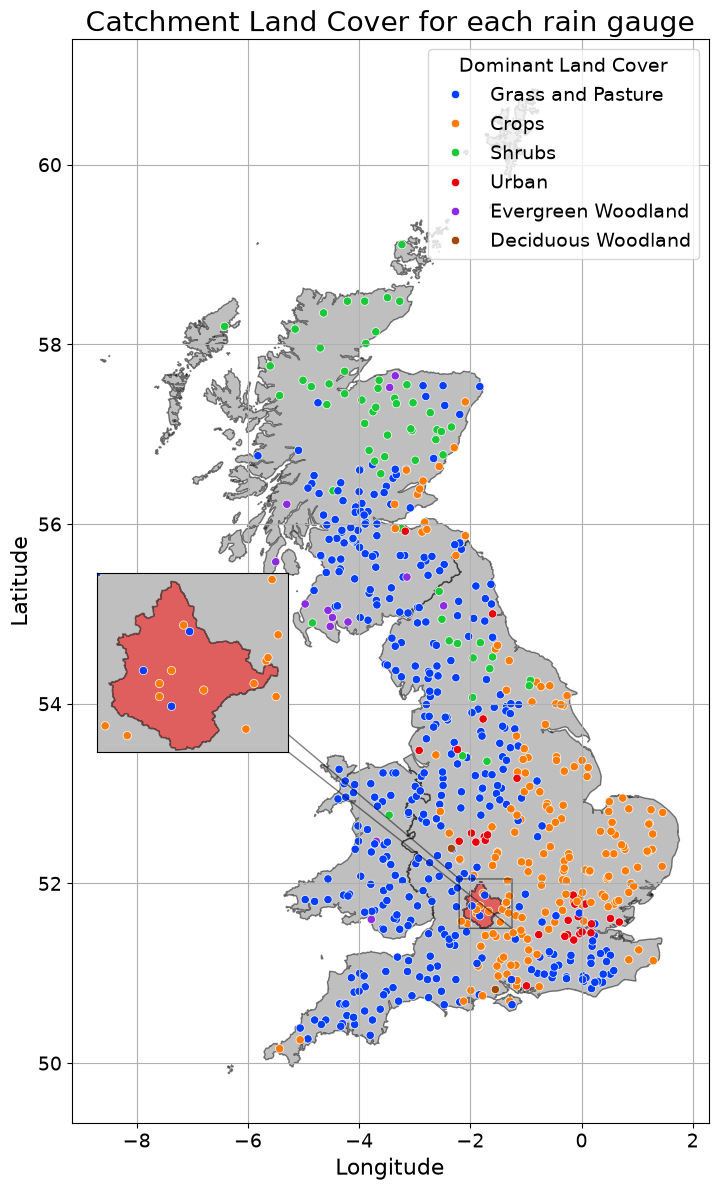

In [3]:
## Plotting the catchment land cover ##

fig, ax = plt.subplots(1, 1, figsize=(8, 12))

# Plotting the gb boundary
gb_boundary.plot(ax=ax, edgecolor="black", facecolor="grey", alpha=0.5)

# Plotting the catchment boundary
catchment_boundary.plot(ax=ax, edgecolor="black", facecolor="red", alpha=0.5)

# Plotting the catchment land cover
sns.scatterplot(
    data=catchment, x="gauge_lon", y="gauge_lat", hue="dom_land_cover", palette="bright", ax=ax
)

# adding plot labels
plt.title("Catchment Land Cover for each rain gauge", fontsize=20)
plt.ylabel("Latitude", fontsize=16)
plt.xlabel("Longitude", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.legend(title="Dominant Land Cover", loc="upper right", fontsize=14, title_fontsize=14)

axins = ax.inset_axes(
    [0.04, 0.275, 0.3, 0.3], xlim=(-2.2, -1.25), ylim=(51.5, 52.05), xticks=[], yticks=[]
)
gb_boundary.plot(ax=axins, edgecolor="black", facecolor="grey", alpha=0.5)
catchment_boundary.plot(ax=axins, edgecolor="black", facecolor="red", alpha=0.5)
sns.scatterplot(
    data=catchment,
    x="gauge_lon",
    y="gauge_lat",
    hue="dom_land_cover",
    palette="bright",
    ax=axins,
    legend=False,
)
ax.indicate_inset_zoom(axins, edgecolor="black")

plt.tight_layout()
plt.savefig(plot_dir / "Catchment_LandCover.svg")
plt.show()
plt.close()

## 1. Catchment water balance

Estimate crop coefficients and compare monthly balances with and without soil-water stress.


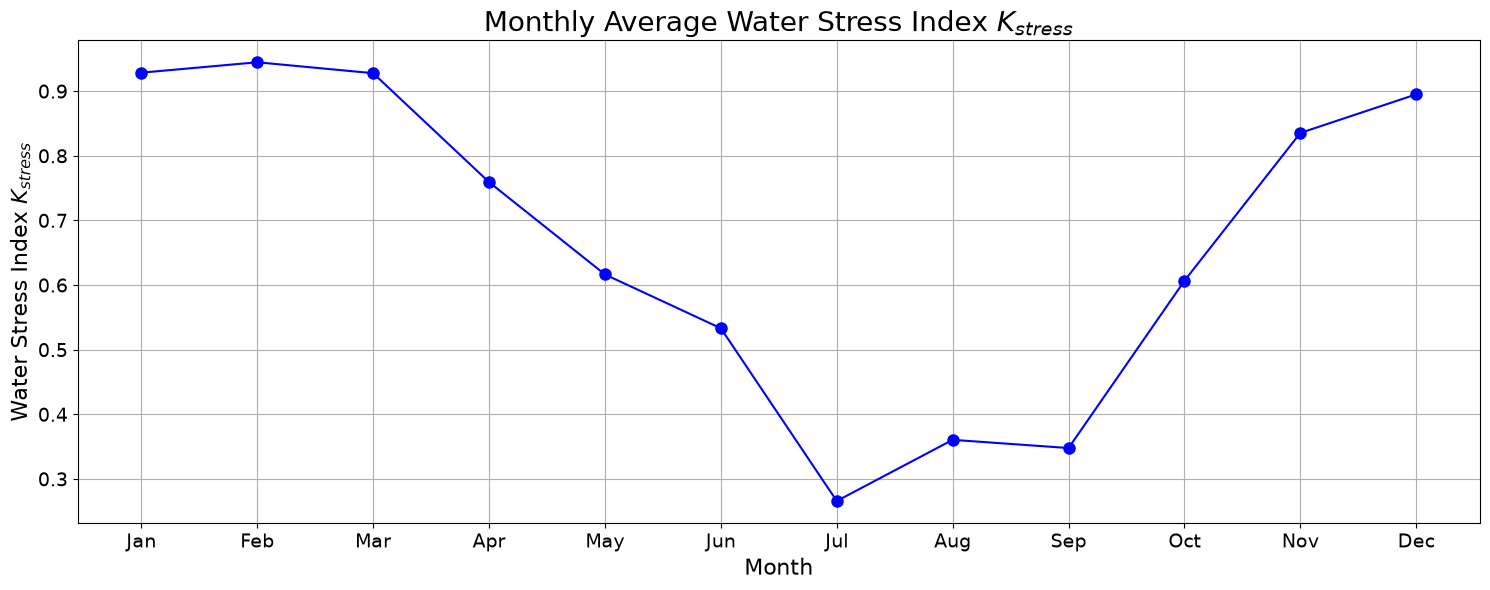

In [4]:
# calculating the water stress index
wilting_point = 20  # for clayey soil
field_capacity = 40  # for clayey soil, Oxfordshire

soil_moisture = soil_moisture.dropna()
soil_moisture = soil_moisture.drop(columns=["SITE_ID"])
soil_moisture["DATE_TIME"] = pd.to_datetime(soil_moisture["DATE_TIME"], dayfirst=True)
soil_moisture = soil_moisture.set_index("DATE_TIME")

# Ensure COSMOS_VWC is numeric
soil_moisture["COSMOS_VWC"] = pd.to_numeric(soil_moisture["COSMOS_VWC"], errors="coerce")

soil_moisture["Kstress"] = (soil_moisture["COSMOS_VWC"] - wilting_point) / (
    field_capacity - wilting_point
)
soil_moisture["Kstress"] = soil_moisture["Kstress"].clip(lower=0, upper=1)


monthly_stress = soil_moisture.groupby(soil_moisture.index.month).mean()
monthly_stress.index.name = "Month"

fig, ax = plt.subplots(1, 1, figsize=(15, 6))
monthly_stress["Kstress"].plot(
    ax=ax, marker="o", color="blue", linestyle="-", linewidth=1.5, markersize=8
)
ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.title("Monthly Average Water Stress Index $K_{stress}$", fontsize=20)
plt.ylabel("Water Stress Index $K_{stress}$", fontsize=16)
plt.xlabel("Month", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.tight_layout()
plt.savefig(plot_dir / "Monthly_WaterStressIndex.svg")
plt.show()
plt.close()

In [5]:
## calculating the PET using the distribution
# distributions obtained from the national river flow archive, https://nrfa.ceh.ac.uk/data/station/spatial/39008
woodland_fraction = 10.80 / 100
grassland_fraction = 35.16 / 100
urban_fraction = 6.67 / 100
arable_fraction = 45.45 / 100
other_fraction = 1.92 / 100

## calculating the kc value for arable land https://www.gov.uk/government/statistics/agricultural-facts-england-regional-profiles/agricultural-facts-south-east-region
# to calculate this I have taken the 3 most common crops in the south east region and calculated the percentage of acreage they cover assuming they represent the whole arable land
barley_fraction = 28.4 / 100
wheat_fraction = 56.6 / 100
rapeseed_fraction = 15 / 100

## other kc values used and mentioned in the lecture slides
kc_woodland = 1  # according to lecture slides
kc_grassland = 1  # according to lecture slides
kc_urban = 0.1  # according to lecture slides
kc_other = 1  # undefined

In [6]:
# Define the number of days in each month
days_in_month = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])

# values of kc have been obtained from: https://www.fao.org/4/X0490E/x0490e0b.htm
# the schema is as follows: sum(kc values for each development period * percentage duration of development period) of crop cycle.
# the kc values are for the following development periods: initial, crop development, mid-season, late season
kc_barley = np.array([0.3, 0.3, 1.15, 1.15, 0.25])
kc_wheat = np.array([0.7, 0.7, 1.15, 1.15, 0.4])  # assuming winter wheat
kc_rapeseed = np.array([0.35, 0.35, 1.15, 1.15, 0.35])

# Duration of each development period as a fraction of the total crop cycle
barley_duration = (
    np.array([0, 0.148, 0.185, 0.444, 0.222]) * 135 / 365
)  # november start, 135 days total
wheat_duration = (
    np.array([0, 0.148, 0.185, 0.444, 0.222]) * 135 / 365
)  # november start, 135 days total
rapeseed_duration = (
    np.array([0, 0.172, 0.241, 0.379, 0.207]) * 145 / 365
)  # march start, 145 days total

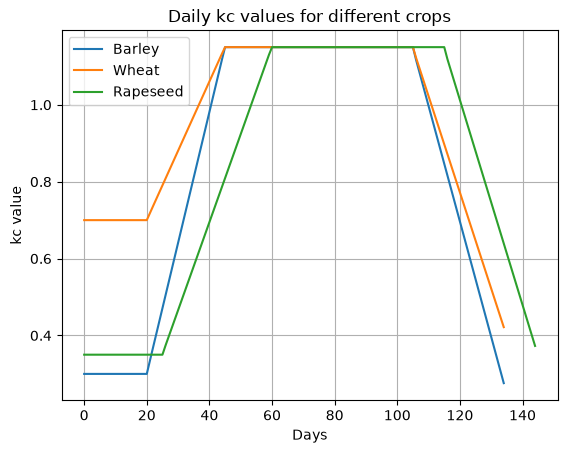

In [7]:
# Function to calculate daily kc values
def kc_crops_daily(
    kc_vals: NDArray[np.float64], crop_duration_cumsum: NDArray[np.float64]
) -> NDArray[np.float64]:
    """
    Function to calculate daily kc values for a crop

    Inputs:
    kc_vals: list of kc values for each development period of the crop
    crop_duration_cumsum: cumulative sum of the duration of each development period of the crop

    Outputs:
    kc: daily kc values for the crop
    """
    length = (crop_duration_cumsum[-1] * 365).round().astype(int)
    lifetime_index = 0
    kc = np.zeros(length)
    for i in range(length):
        if i <= crop_duration_cumsum[lifetime_index + 1] * 365:
            if kc_vals[lifetime_index] == kc_vals[lifetime_index + 1]:
                kc[i] = kc_vals[lifetime_index]
            else:
                kc[i] = kc_vals[lifetime_index] + (
                    kc_vals[lifetime_index + 1] - kc_vals[lifetime_index]
                ) * (i - crop_duration_cumsum[lifetime_index] * 365) / (
                    crop_duration_cumsum[lifetime_index + 1] * 365
                    - crop_duration_cumsum[lifetime_index] * 365
                )
        else:
            lifetime_index += 1
            kc[i] = kc_vals[lifetime_index]
    return kc


barley_daily_kc = kc_crops_daily(kc_barley, np.cumsum(barley_duration))
wheat_daily_kc = kc_crops_daily(kc_wheat, np.cumsum(wheat_duration))
rapeseed_daily_kc = kc_crops_daily(kc_rapeseed, np.cumsum(rapeseed_duration))

# plotting the daily kc values
plt.plot(barley_daily_kc)
plt.plot(wheat_daily_kc)
plt.plot(rapeseed_daily_kc)
plt.xlabel("Days")
plt.ylabel("kc value")
plt.title("Daily kc values for different crops")
plt.legend(["Barley", "Wheat", "Rapeseed"])
plt.grid()

plt.savefig(plot_dir / "Daily_kc_values.svg")
plt.show()
plt.close()

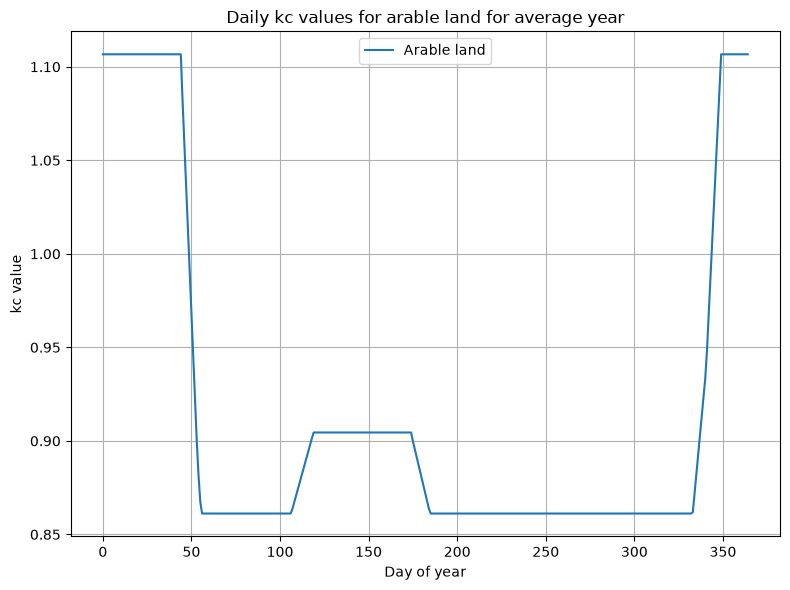

In [8]:
# factor to determine the minimum kc value when crops are not growing, this is taken as the average kc for all crops listed
factor = (
    np.sum(
        kc_barley * barley_duration + kc_wheat * wheat_duration + kc_rapeseed * rapeseed_duration
    )
    * 365
    / (135 + 135 + 145)
)

barley_daily_kc[barley_daily_kc < factor] = factor
wheat_daily_kc[wheat_daily_kc < factor] = factor
rapeseed_daily_kc[rapeseed_daily_kc < factor] = factor

# combining the arable land kc values
yearsindays = np.linspace(0, 365 * 3, 365 * 3)
kcyearsindays = np.ones(len(yearsindays)) * factor  # start with all kc values as 1

# year 1
# add the kc values for the different to yearsindays at starting months
# add wheat kc values at the start of november
kcyearsindays[304:439] += (wheat_daily_kc - factor) * wheat_fraction
# add barley kc values at the start of november
kcyearsindays[304:439] += (barley_daily_kc - factor) * barley_fraction
# add rapeseed kc values at the start of march
kcyearsindays[59:204] += (rapeseed_daily_kc - factor) * rapeseed_fraction

# year 2
# add wheat kc values at the start of november
kcyearsindays[304 + 365 : 439 + 365] += (wheat_daily_kc - factor) * wheat_fraction
# add barley kc values at the start of november
kcyearsindays[304 + 365 : 439 + 365] += (barley_daily_kc - factor) * barley_fraction
# add rapeseed kc values at the start of march
kcyearsindays[59 + 365 : 204 + 365] += (rapeseed_daily_kc - factor) * rapeseed_fraction

kc_arable_year = kcyearsindays[365 : 365 * 2]

# plotting the daily kc values
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.plot(kc_arable_year)
plt.xlabel("Day of year")
plt.ylabel("kc value")
plt.title("Daily kc values for arable land for average year")
plt.legend(["Arable land"])
plt.grid()
plt.tight_layout()
plt.savefig(plot_dir / "Arable_kc_values.svg")
plt.show()
plt.close()

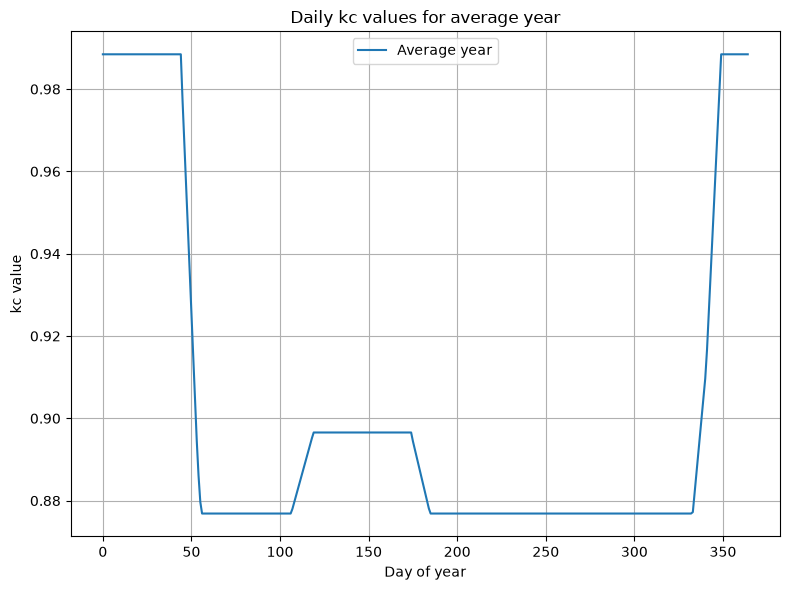

In [9]:
# adding other land cover kc values to the array
kc_yearly = (
    arable_fraction * kc_arable_year
    + woodland_fraction * kc_woodland
    + grassland_fraction * kc_grassland
    + urban_fraction * kc_urban
    + other_fraction * kc_other
)

# plotting the daily kc values
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.plot(kc_yearly)
plt.xlabel("Day of year")
plt.ylabel("kc value")
plt.title("Daily kc values for average year")
plt.legend(["Average year"])
plt.grid()
plt.tight_layout()
plt.savefig(plot_dir / "Average_kc_values.svg")
plt.show()
plt.close()

In [10]:
# The 365-day sequence starts at the first record (October),
# without calendar-month alignment or leap-day handling.
# calculating the PET using the kc values for each day of the year

kc_yearly_repeated = np.tile(kc_yearly, len(hydrometeorology) // len(kc_yearly) + 1)[
    : len(hydrometeorology)
]
hydrometeorology["PETc"] = hydrometeorology["peti"] * kc_yearly_repeated

### Monthly water-balance calculations


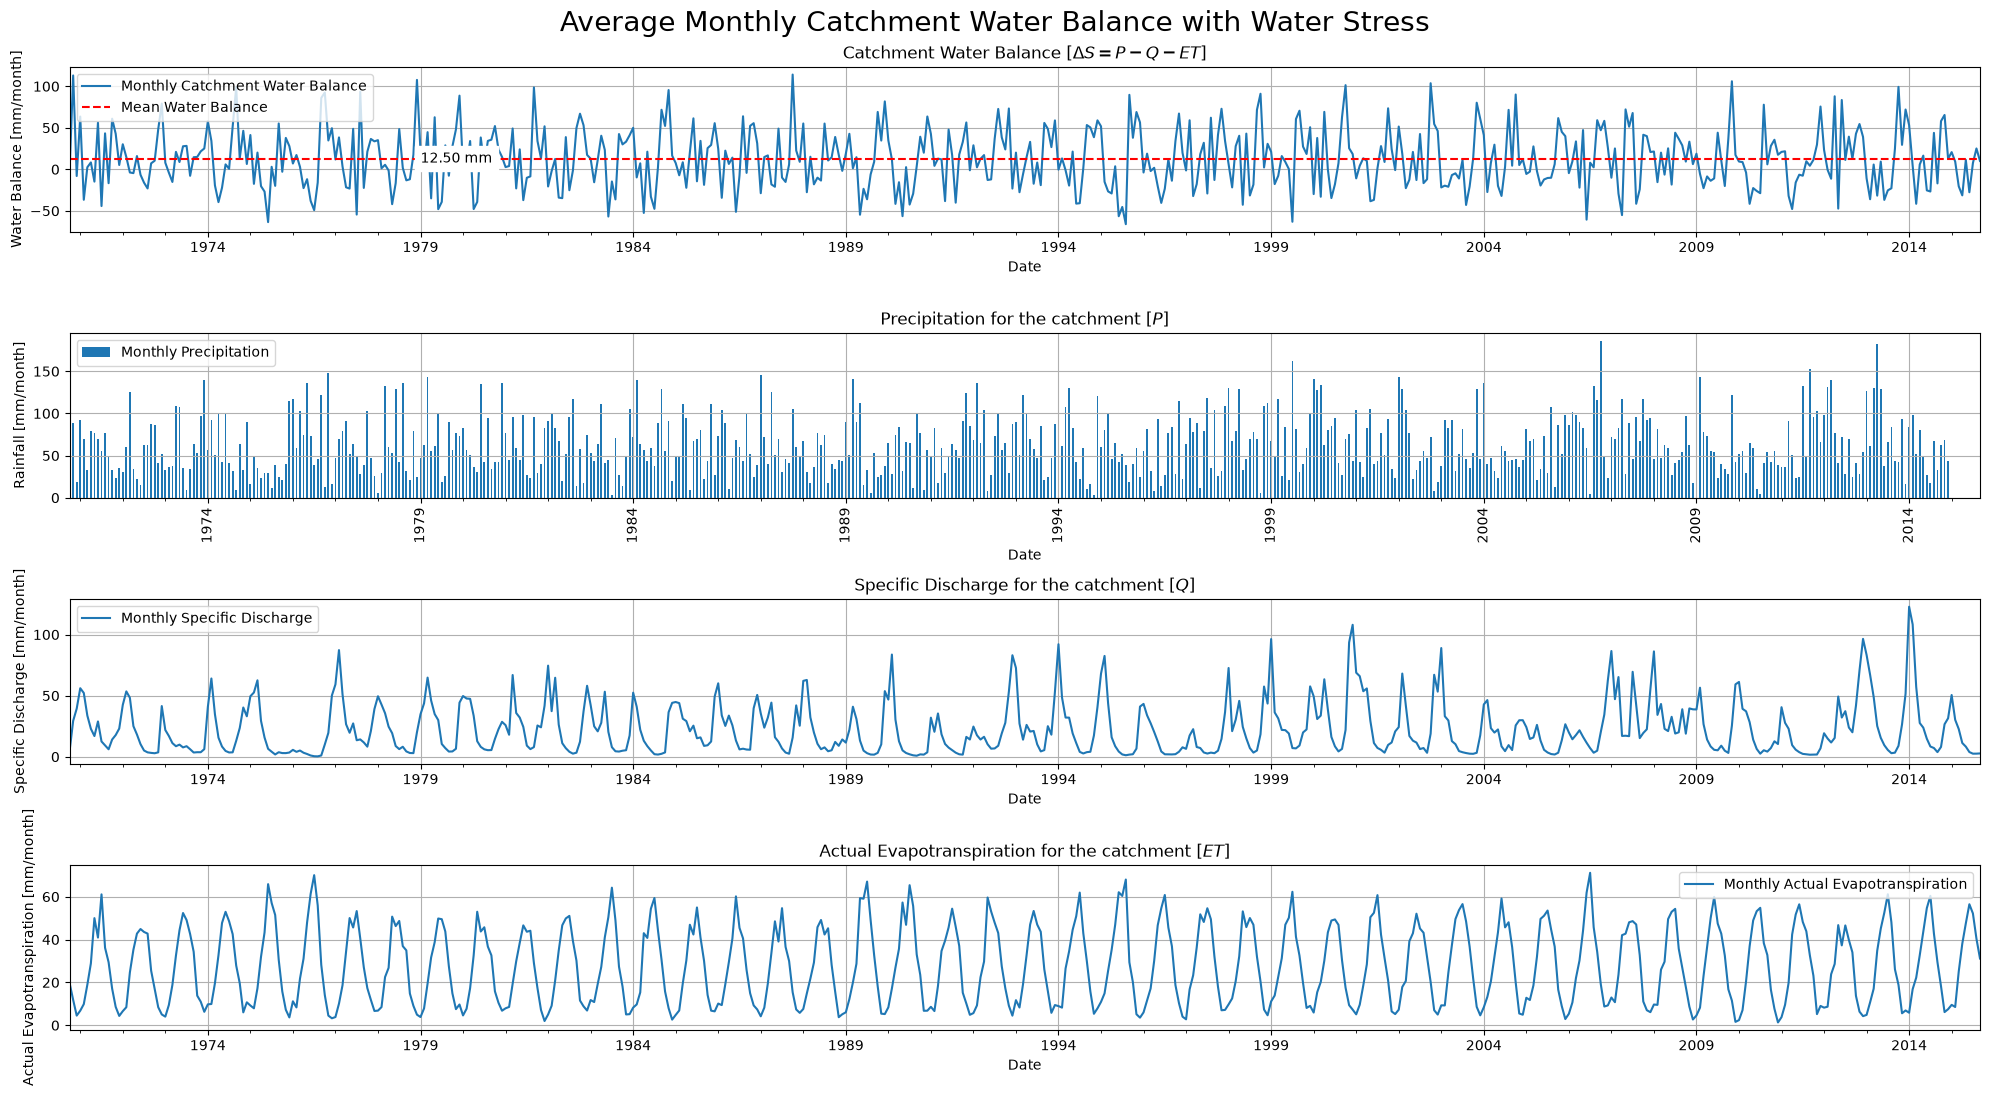

In [11]:
# Monthly factors cycle every 12 daily rows rather than matching calendar months.
# Calculating the evapotranspiration using the kstress value
hydrometeorology["Kstress"] = np.tile(
    monthly_stress["Kstress"].values, len(hydrometeorology) // 12 + 1
)[: len(hydrometeorology)]
hydrometeorology["ActualEvapotranspiration"] = (
    hydrometeorology["PETc"] * hydrometeorology["Kstress"]
)

# calculating overall catchment water balance
hydrometeorology["CatchmentWaterBalance"] = (
    hydrometeorology["precipitation"]
    - hydrometeorology["discharge_spec"]
    - hydrometeorology["ActualEvapotranspiration"]
)

hydrocalc = hydrometeorology.resample("ME").sum()
mean_cwb = hydrocalc["CatchmentWaterBalance"].mean()

fig, ax = plt.subplots(4, 1, figsize=(20, 11))
fig.suptitle("Average Monthly Catchment Water Balance with Water Stress", fontsize=20)

# Plotting the data
hydrocalc.plot(
    y="CatchmentWaterBalance",
    title=r"Catchment Water Balance [$\Delta S = P - Q - ET$]",
    ylabel="Water Balance [mm/month]",
    xlabel="Date",
    grid=True,
    ax=ax[0],
    kind="line",
    label="Monthly Catchment Water Balance",
)
ax[0].axhline(
    y=mean_cwb,
    color="r",
    linestyle="--",
    label="Mean Water Balance",
)
ax[0].text(
    pd.to_datetime("1979-01"),
    mean_cwb,
    f"{mean_cwb:.2f} mm",
    fontsize=10,
    verticalalignment="center",
    horizontalalignment="left",
    backgroundcolor="white",
)
ax[0].legend()

hydrocalc.plot(
    y="precipitation",
    title=r"Precipitation for the catchment [$P$]",
    ylabel="Rainfall [mm/month]",
    xlabel="Date",
    grid=True,
    ax=ax[1],
    kind="bar",
    label="Monthly Precipitation",
)
hydrocalc.plot(
    y="discharge_spec",
    title=r"Specific Discharge for the catchment [$Q$]",
    ylabel="Specific Discharge [mm/month]",
    xlabel="Date",
    grid=True,
    ax=ax[2],
    label="Monthly Specific Discharge",
)
hydrocalc.plot(
    y="ActualEvapotranspiration",
    title=r"Actual Evapotranspiration for the catchment [$ET$]",
    ylabel="Actual Evapotranspiration [mm/month]",
    xlabel="Date",
    grid=True,
    ax=ax[3],
    label="Monthly Actual Evapotranspiration",
)


for a in ax[1:]:
    a.sharex(ax[0])

plt.tight_layout()
plt.savefig(plot_dir / "Catchment_WaterBalance.svg")
plt.show()
plt.close()

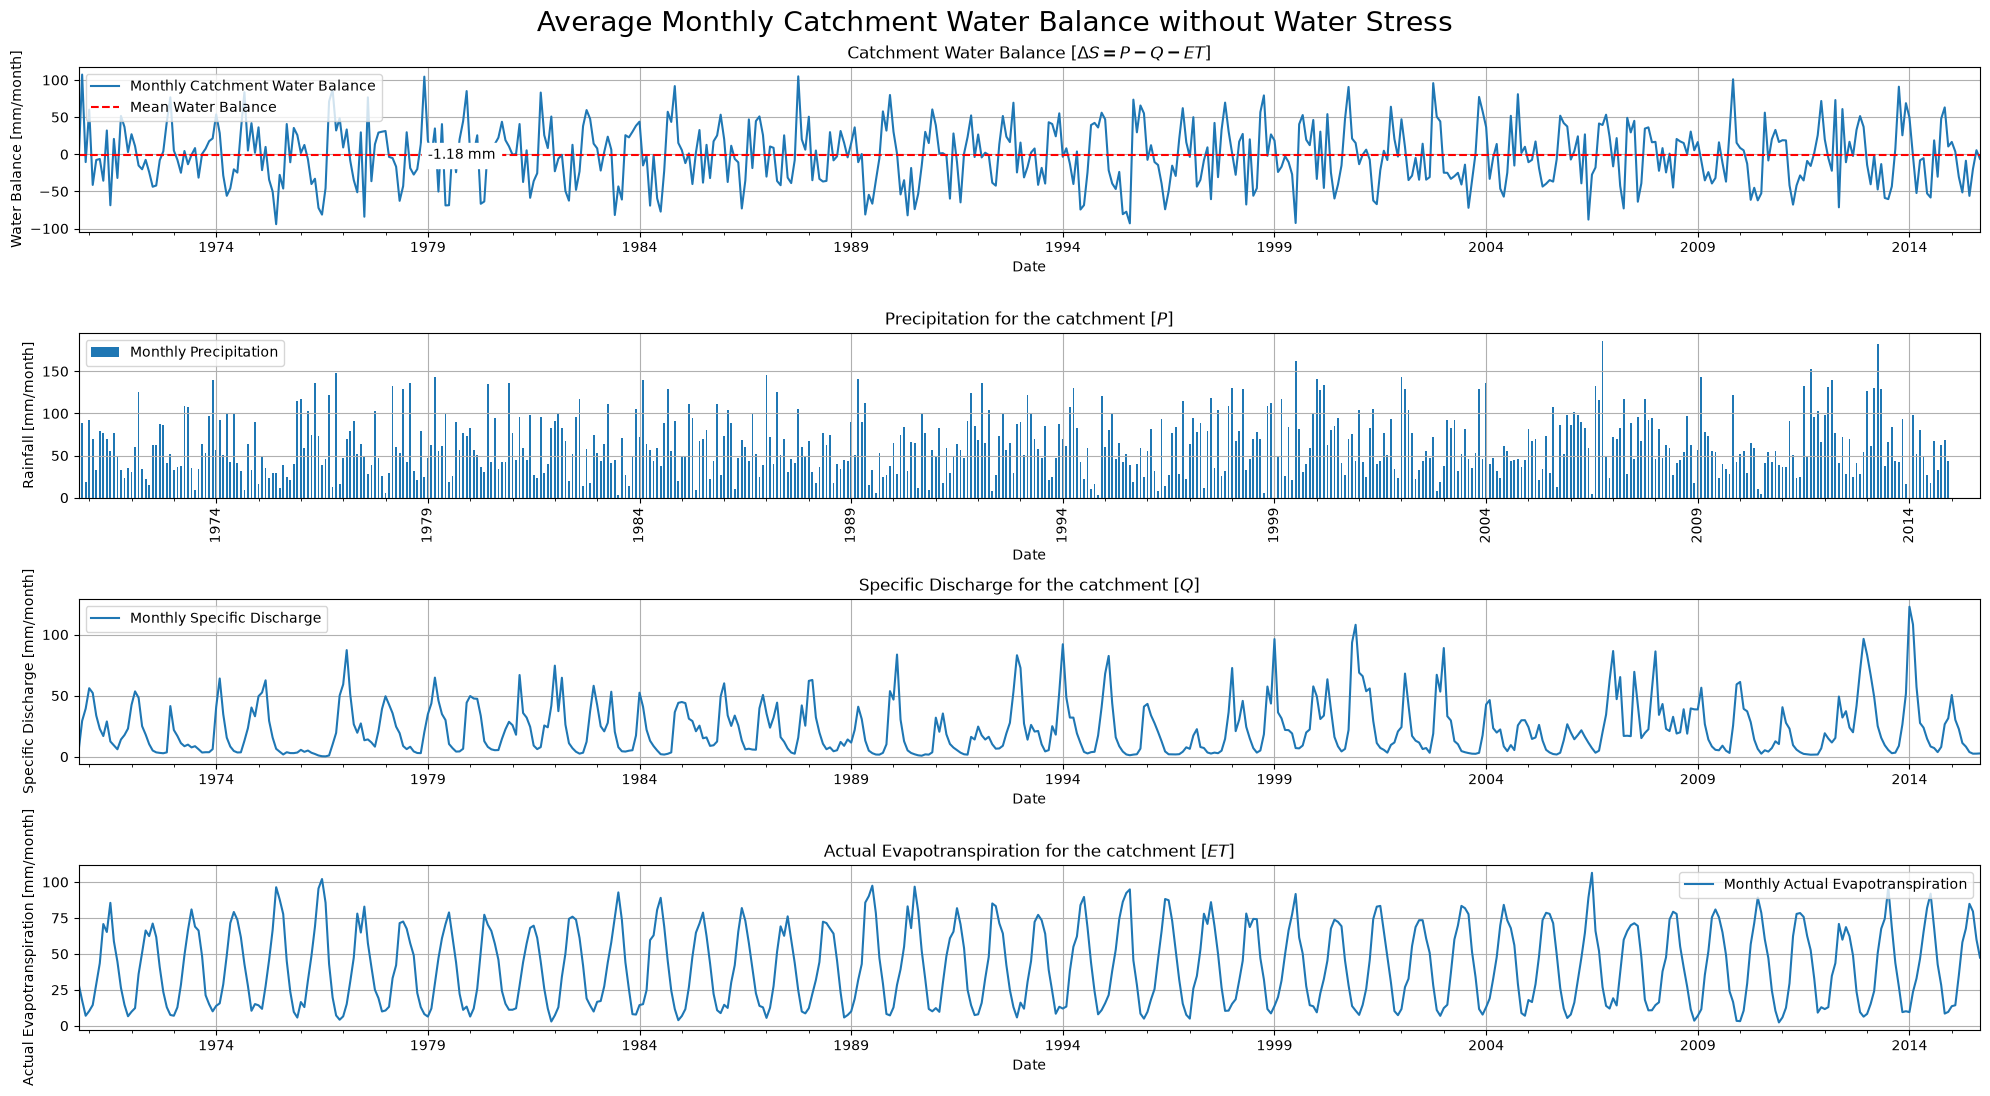

In [12]:
# without water stress

hydrometeorology["ActualEvapotranspiration_noStress"] = hydrometeorology["PETc"]

# calculating overall catchment water balance
hydrometeorology["CatchmentWaterBalance_noStress"] = (
    hydrometeorology["precipitation"]
    - hydrometeorology["discharge_spec"]
    - hydrometeorology["ActualEvapotranspiration_noStress"]
)

monthly_balance_no_stress = hydrometeorology.resample("ME").sum()
mean_balance_no_stress = monthly_balance_no_stress["CatchmentWaterBalance_noStress"].mean()

fig, ax = plt.subplots(4, 1, figsize=(20, 11))
fig.suptitle("Average Monthly Catchment Water Balance without Water Stress", fontsize=20)

# Plotting the data
monthly_balance_no_stress.plot(
    y="CatchmentWaterBalance_noStress",
    title=r"Catchment Water Balance [$\Delta S = P - Q - ET$]",
    ylabel="Water Balance [mm/month]",
    xlabel="Date",
    grid=True,
    ax=ax[0],
    kind="line",
    label="Monthly Catchment Water Balance",
)
ax[0].axhline(
    y=mean_balance_no_stress,
    color="r",
    linestyle="--",
    label="Mean Water Balance",
)
ax[0].text(
    pd.to_datetime("1979-01"),
    mean_balance_no_stress,
    f"{mean_balance_no_stress:.2f} mm",
    fontsize=10,
    verticalalignment="center",
    horizontalalignment="left",
    backgroundcolor="white",
)
ax[0].legend()

monthly_balance_no_stress.plot(
    y="precipitation",
    title=r"Precipitation for the catchment [$P$]",
    ylabel="Rainfall [mm/month]",
    xlabel="Date",
    grid=True,
    ax=ax[1],
    kind="bar",
    label="Monthly Precipitation",
)
monthly_balance_no_stress.plot(
    y="discharge_spec",
    title=r"Specific Discharge for the catchment [$Q$]",
    ylabel="Specific Discharge [mm/month]",
    xlabel="Date",
    grid=True,
    ax=ax[2],
    label="Monthly Specific Discharge",
)
monthly_balance_no_stress.plot(
    y="ActualEvapotranspiration_noStress",
    title=r"Actual Evapotranspiration for the catchment [$ET$]",
    ylabel="Actual Evapotranspiration [mm/month]",
    xlabel="Date",
    grid=True,
    ax=ax[3],
    label="Monthly Actual Evapotranspiration",
)


for a in ax[1:]:
    a.sharex(ax[0])

plt.tight_layout()
plt.savefig(plot_dir / "Catchment_WaterBalance_noStress.svg")
plt.show()
plt.close()

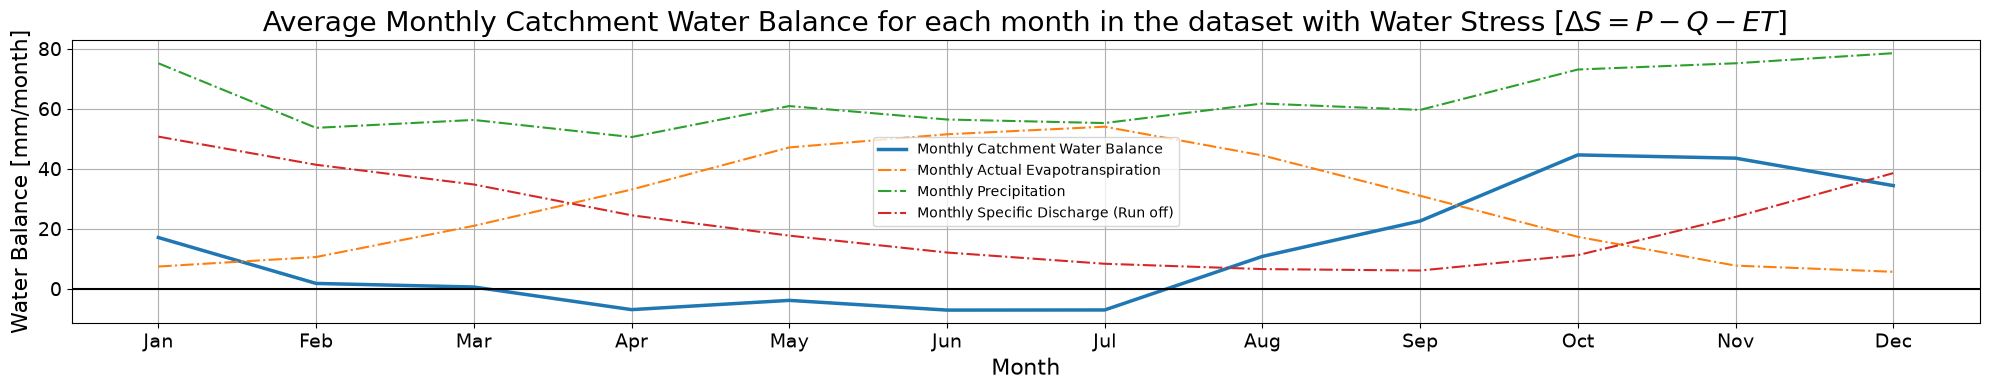

In [13]:
# calculating the average monthly water balance for the catchment
hydrocalc["month"] = hydrocalc.index.month
results = hydrocalc.groupby("month").mean()

fig, ax = plt.subplots(1, 1, figsize=(20, 4))
results.plot(
    y="CatchmentWaterBalance",
    ax=ax,
    kind="line",
    label="Monthly Catchment Water Balance",
    linewidth=2.5,
)

# Plotting the water balance
results.plot(
    y="ActualEvapotranspiration",
    ax=ax,
    kind="line",
    label="Monthly Actual Evapotranspiration",
    linestyle="-.",
)
results.plot(y="precipitation", ax=ax, kind="line", label="Monthly Precipitation", linestyle="-.")
results.plot(
    y="discharge_spec",
    ax=ax,
    kind="line",
    label="Monthly Specific Discharge (Run off)",
    linestyle="-.",
)

ax.axhline(y=0, color="k", linestyle="-")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
ax.set_xlabel("Month", fontsize=16)
ax.set_ylabel("Water Balance [mm/month]", fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=14)
plt.title(
    r"Average Monthly Catchment Water Balance for each month in the dataset with Water Stress [$\Delta S = P - Q - ET$]",
    fontsize=20,
)
plt.tight_layout()
plt.grid()
plt.legend()
plt.savefig(plot_dir / "Catchment_WaterBalance_Monthly.svg")
plt.show()
plt.close()

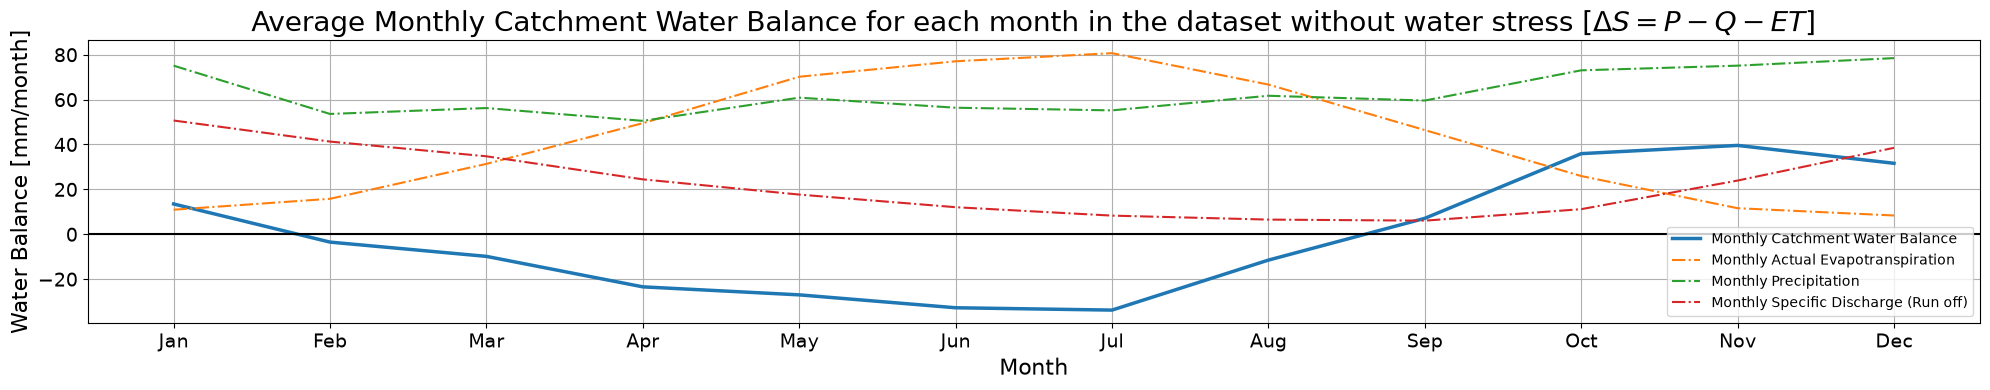

In [14]:
# calculating the average monthly water balance for the catchment without water stress
monthly_balance_no_stress["month"] = monthly_balance_no_stress.index.month
monthly_means_no_stress = monthly_balance_no_stress.groupby("month").mean()

fig, ax = plt.subplots(1, 1, figsize=(20, 4))
monthly_means_no_stress.plot(
    y="CatchmentWaterBalance_noStress",
    ax=ax,
    kind="line",
    label="Monthly Catchment Water Balance",
    linewidth=2.5,
)
# Plotting the water balance
monthly_means_no_stress.plot(
    y="ActualEvapotranspiration_noStress",
    ax=ax,
    kind="line",
    label="Monthly Actual Evapotranspiration",
    linestyle="-.",
)
monthly_means_no_stress.plot(
    y="precipitation", ax=ax, kind="line", label="Monthly Precipitation", linestyle="-."
)
monthly_means_no_stress.plot(
    y="discharge_spec",
    ax=ax,
    kind="line",
    label="Monthly Specific Discharge (Run off)",
    linestyle="-.",
)
ax.axhline(y=0, color="k", linestyle="-")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
ax.set_xlabel("Month", fontsize=16)
ax.set_ylabel("Water Balance [mm/month]", fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=14)
plt.title(
    r"Average Monthly Catchment Water Balance for each month in the dataset without water stress [$\Delta S = P - Q - ET$]",
    fontsize=20,
)
plt.tight_layout()
plt.grid()
plt.legend()
plt.savefig(plot_dir / "Catchment_WaterBalance_Monthly_noStress.svg")
plt.show()
plt.close()

## 2. Annual precipitation–crop-demand balance

The annual balance is **precipitation minus crop PET**. Positive values
represent a surplus, not irrigation demand. The reported average of 255.66 mm/year
uses this sign convention. Irrigation demand cannot be inferred directly from
this annual balance. The first and last calendar years contain only part of a year.


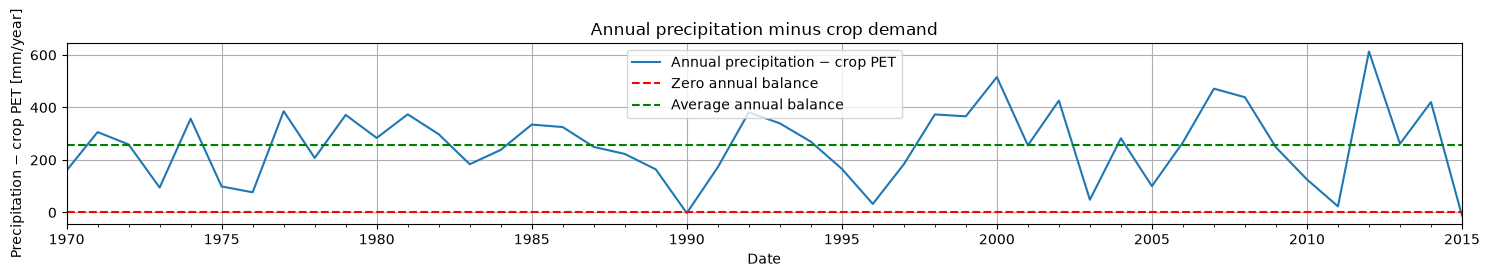

In [15]:
annual_balance = hydrometeorology.resample("YE").sum()
annual_balance["AnnualWaterBalance"] = annual_balance["precipitation"] - annual_balance["PETc"]
mean_annual_balance = annual_balance["AnnualWaterBalance"].mean()

fig, ax = plt.subplots(1, 1, figsize=(15, 2.75))
annual_balance.plot(
    y="AnnualWaterBalance",
    title="Annual precipitation minus crop demand",
    ylabel="Precipitation − crop PET [mm/year]",
    xlabel="Date",
    grid=True,
    ax=ax,
    label="Annual precipitation − crop PET",
)
ax.axhline(y=0, color="r", linestyle="--", label="Zero annual balance")
ax.axhline(y=mean_annual_balance, color="g", linestyle="--", label="Average annual balance")
ax.legend()
plt.tight_layout()
plt.savefig(plot_dir / "Annual_Irrigation_Need.svg")
plt.show()
plt.close()

## 3. Rainfall–runoff model calibration

Minimise the sum of squared discharge residuals using Nelder–Mead.


The calibration objective is the sum of squared residuals between observed and simulated total discharge.
The model and objective function are defined in `model.py`.

### Chronological 80:20 calibration and evaluation split


In [16]:
# preparing the data for the optimisation
# hydrological data
rainfall = (
    hydrometeorology["precipitation"].to_numpy(dtype=float) / 24
)  # converting the rainfall data from mm/day to mm/hr
potential_evapotranspiration = (
    hydrometeorology["PETc"].to_numpy(dtype=float) / 24
)  # potential evapotranspiration specific to the catchment in mm/hr
observed_flow = (
    hydrometeorology["discharge_spec"].to_numpy(dtype=float) / 24
)  # observed flow data in mm/h
dates = hydrometeorology.index

# calculating the training data fraction
training_fraction = 0.8
training_size = int(len(rainfall) * training_fraction)

rainfall_train = rainfall[:training_size]
pet_train = potential_evapotranspiration[:training_size]
observed_flow_train = observed_flow[:training_size]
dates_train = dates[:training_size]

# testing data
testing_size = len(rainfall) - training_size
rainfall_test = rainfall[training_size:]
pet_test = potential_evapotranspiration[training_size:]
observed_flow_test = observed_flow[training_size:]
dates_test = dates[training_size:]

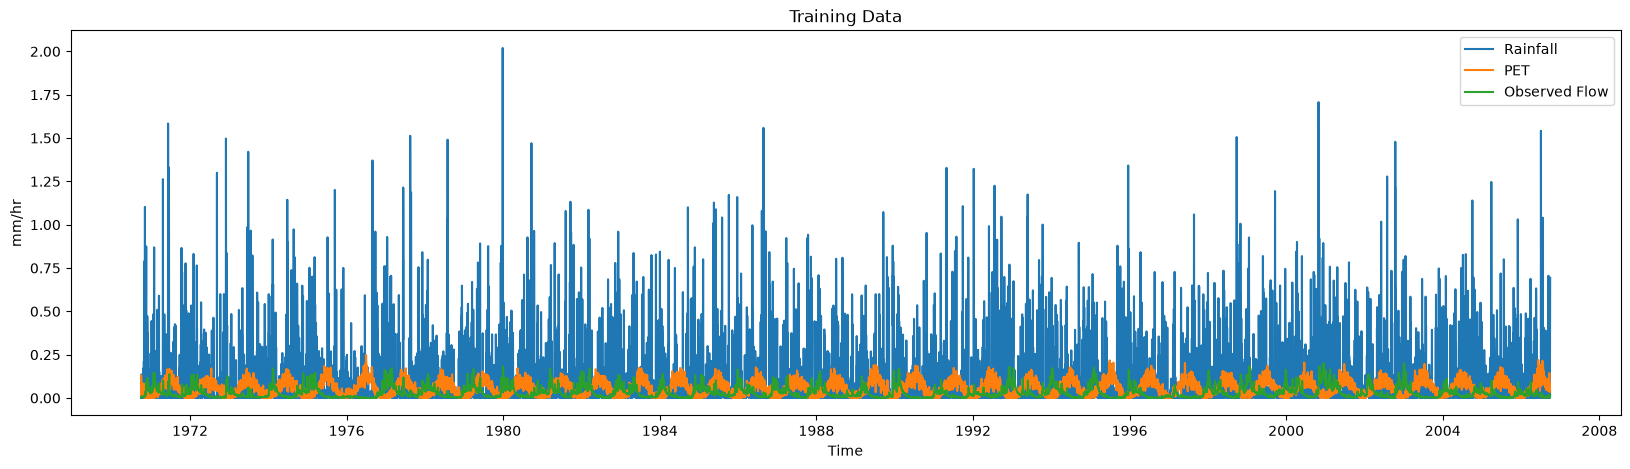

In [17]:
# plotting training data
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
ax.plot(dates_train, rainfall_train, label="Rainfall")
ax.plot(dates_train, pet_train, label="PET")
ax.plot(dates_train, observed_flow_train, label="Observed Flow")


ax.set_xlabel("Time")
ax.set_ylabel("mm/hr")
ax.set_title("Training Data")
ax.legend()
plt.savefig(plot_dir / "Training_Data.svg")
plt.show()
plt.close()

### Initial parameters and states


In [18]:
## initial inputs for the model

# %% Set up the parameters
Zr = 1000.0  # [mm]
n1 = 0.5  # [-]
Ks = 5.0  # [mm/h]
Ksb = 0.1  # [mm/h]
Zg = 5000.0  # [mm]
n2 = 0.5  # [-]

b = 10.0  # [-]
c = 0.1  # [mm/h]
d = 1.5  # [-]

T1 = 24 * 2.0  # [h]
T2 = 24 * 10.0  # [h]
DT = 24.0  # [h]

groundwater_abstraction = 0.01 * np.ones(
    (len(rainfall),)
)  # [mm/h] - groundwater abstraction series
abstraction_train = 0.01 * np.ones((training_size,))  # [mm/h] - groundwater abstraction series
abstraction_test = 0.01 * np.ones((testing_size,))  # [mm/h] - groundwater abstraction series

S1_ini = 0.5 * n1 * Zr  # [mm]
S2_ini = 0.5 * n2 * Zg  # [mm]
V1_ini = 50.0  # [mm]
V2_ini = 50.0  # [mm]

initial_parameters = (Zr, n1, Ks, Ksb, Zg, n2, b, c, d, T1, T2, DT)
initial_states = (S1_ini, S2_ini, V1_ini, V2_ini)

### Uncalibrated simulation


In [19]:
# Run the model with uncalibrated parameters
Qs_uncal, Qb_uncal, S1_uncal, S2_uncal, V1_uncal, V2_uncal = simulate(
    initial_parameters,
    initial_states,
    rainfall,
    potential_evapotranspiration,
    groundwater_abstraction,
)

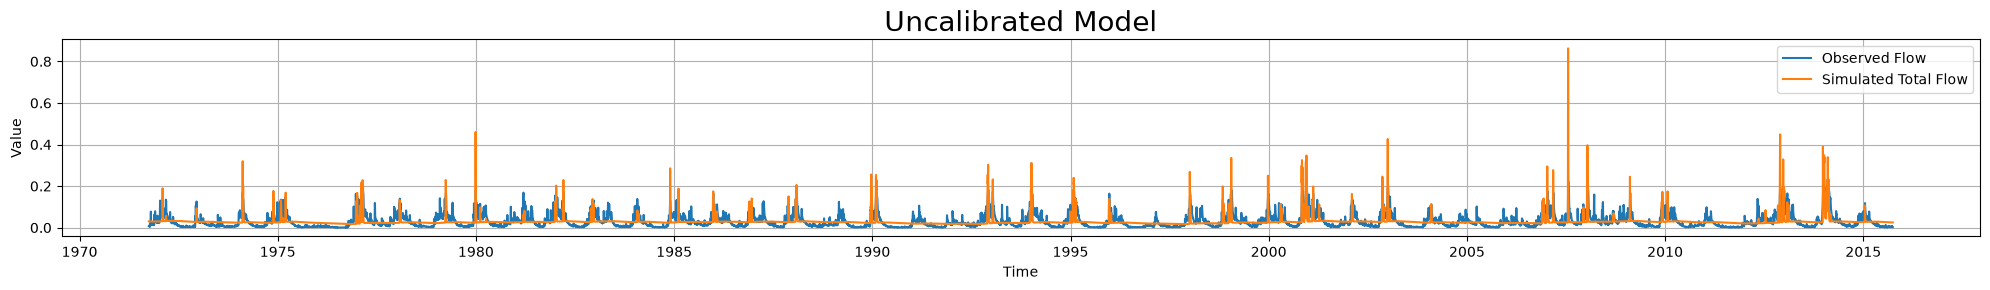

In [20]:
# Define the index to cut off the first year
cut_off_index = 365

# Plotting the uncalibrated model
fig, ax = plt.subplots(1, 1, figsize=(20, 3))

ax.plot(dates[cut_off_index:], observed_flow[cut_off_index:], label="Observed Flow")
ax.plot(dates[cut_off_index:], (Qs_uncal + Qb_uncal)[cut_off_index:], label="Simulated Total Flow")

ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_title("Uncalibrated Model", fontsize=20)
ax.legend()
ax.grid()

plt.tight_layout()
plt.savefig(plot_dir / "Uncalibrated_Model.svg")
plt.show()
plt.close()

### Nelder–Mead calibration

All 12 parameters, including `DT`,
are allowed to vary with non-negative bounds. Porosity is not bounded by one.
The resulting parameters can therefore be physically implausible. Initial states
are fixed during calibration; the objective includes spin-up, while the displayed
full-record errors omit the first 365 rows. The test simulation restarts from the
initial states. A lower unnormalised sum of squares over a shorter test record
alone does not establish better predictive performance.


In [21]:
bounds = [
    (0, None),  # Zr: Root zone depth [mm]
    (0, None),  # n1: Porosity of root zone [-]
    (0, None),  # Ks: Saturated hydraulic conductivity [mm/h]
    (0, None),  # Ksb: Baseflow coefficient [mm/h]
    (0, None),  # Zg: Groundwater depth [mm]
    (0, None),  # n2: Porosity of groundwater zone [-]
    (0, None),  # b: Recharge exponent [-]
    (0, None),  # c: Baseflow coefficient [mm/h]
    (0, None),  # d: Baseflow exponent [-]
    (0, None),  # T1: Time constant for surface runoff [h]
    (0, None),  # T2: Time constant for baseflow [h]
    (0, None),  # DT: Time step [h]
]

# Calibration with Nelder-Mead
opt_result = minimize(
    objective_function,
    initial_parameters,
    args=(initial_states, rainfall_train, pet_train, abstraction_train, observed_flow_train),
    method="Nelder-Mead",
    options={"maxiter": 10000, "disp": True},
    bounds=bounds,
)

Optimization terminated successfully.
         Current function value: 2.425144
         Iterations: 5210
         Function evaluations: 7329


In [22]:
print("Optimal Parameters:", opt_result.x)
print("Function Value at Optimal Parameters (Least squares):", opt_result.fun)
print("Optimization Success:", opt_result.success)

Optimal Parameters: [1.99370751e+05 7.14949778e-03 2.74576546e+02 2.28555343e-01
 7.89411900e+03 9.30260742e+00 3.93796186e+03 2.06561319e+00
 9.53121520e-01 2.27358487e+03 1.33556493e+02 1.13994340e+02]
Function Value at Optimal Parameters (Least squares): 2.425144158845952
Optimization Success: True


In [23]:
# creating model with optimal parameters
Qs, Qb, S1, S2, V1, V2 = simulate(
    opt_result.x, initial_states, rainfall, potential_evapotranspiration, groundwater_abstraction
)
Qs_test, Qb_test, S1_test, S2_test, V1_test, V2_test = simulate(
    opt_result.x, initial_states, rainfall_test, pet_test, abstraction_test
)

### Calibrated simulation and residuals


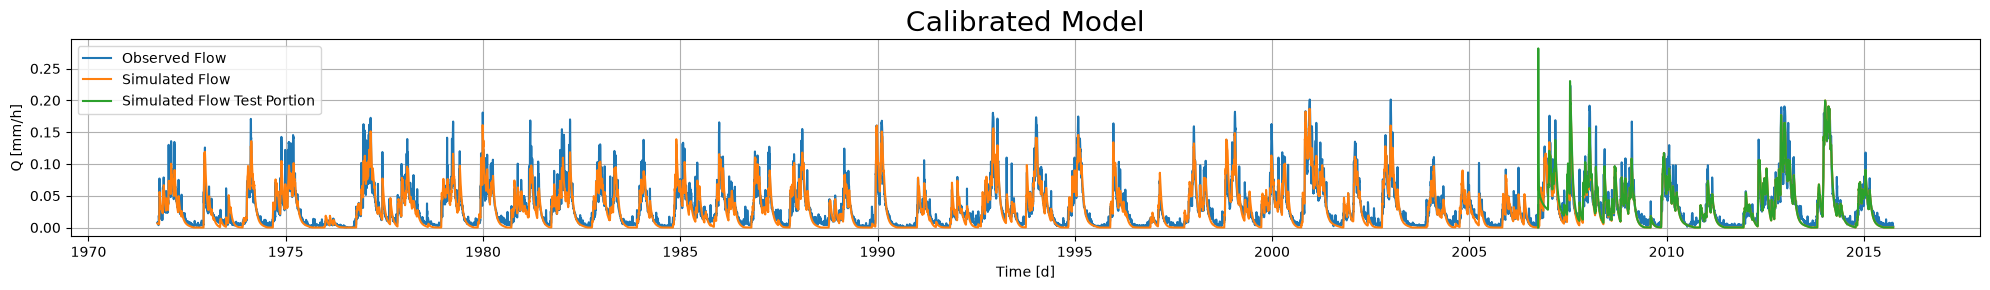

In [24]:
# Plotting the calibrated model
fig1, ax1 = plt.subplots(1, 1, figsize=(20, 3))
ax1.plot(dates[cut_off_index:], observed_flow[cut_off_index:], label="Observed Flow")
ax1.plot(dates[cut_off_index:], (Qs + Qb)[cut_off_index:], label="Simulated Flow")
ax1.plot(dates[training_size:], (Qs_test + Qb_test), label="Simulated Flow Test Portion")
ax1.set_xlabel("Time [d]")
ax1.set_ylabel("Q [mm/h]")
ax1.set_title("Calibrated Model", fontsize=20)
ax1.legend()
ax1.grid()

plt.tight_layout()
plt.savefig(plot_dir / "Calibrated_Model.svg")
plt.show()
plt.close()

In [25]:
# calculating the error of the models
error_uncal = least_squares(
    observed_flow[cut_off_index:], Qs_uncal[cut_off_index:] + Qb_uncal[cut_off_index:]
)
error_cal = least_squares(observed_flow[cut_off_index:], Qs[cut_off_index:] + Qb[cut_off_index:])
error_cal_test = least_squares(observed_flow_test, Qs_test + Qb_test)

print(f"Error of the uncalibrated model (Least Squares): {error_uncal}")
print(f"Error of the calibrated model (Least Squares): {error_cal}")
print(f"Error of the calibrated model on the test portion (Least Squares): {error_cal_test}")

Error of the uncalibrated model (Least Squares): 13.193141674704119
Error of the calibrated model (Least Squares): 2.600951649600736
Error of the calibrated model on the test portion (Least Squares): 0.8557737619175529


## 4. Groundwater comparison

Compare standardised groundwater levels and the monthly normal-scores Standardised Groundwater Index (SGI).


In [26]:
# Groundwater observations indexed by month end.
gw = groundwater_data.dropna().copy()
gw.index = pd.to_datetime(gw["month"], format="%Y-%m") + pd.offsets.MonthEnd(0)
gw = gw.drop(columns="month").astype(float)
gw.head()

,sgi,GW levels (mAOD)
month,,
1959-01-31,0.375,100.4875
1959-02-28,0.687,100.8931
1959-03-31,-0.898,98.8326
1959-04-30,-0.547,99.2889
1959-05-31,0.547,100.7111


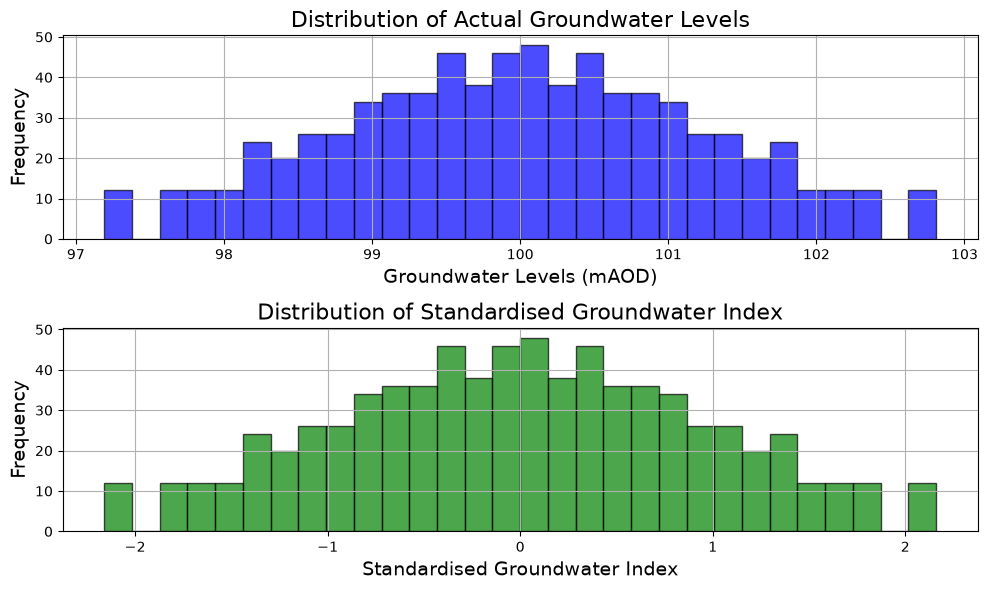

In [27]:
# Plotting the distribution of actual groundwater levels
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
gw["GW levels (mAOD)"].plot(
    kind="hist", bins=30, ax=ax[0], alpha=0.7, color="blue", edgecolor="black"
)
gw["sgi"].plot(kind="hist", bins=30, ax=ax[1], alpha=0.7, color="green", edgecolor="black")

# Adding plot labels
ax[0].set_title("Distribution of Actual Groundwater Levels", fontsize=16)
ax[0].set_xlabel("Groundwater Levels (mAOD)", fontsize=14)
ax[0].set_ylabel("Frequency", fontsize=14)
ax[0].grid(True)

ax[1].set_title("Distribution of Standardised Groundwater Index", fontsize=16)
ax[1].set_xlabel("Standardised Groundwater Index", fontsize=14)
ax[1].set_ylabel("Frequency", fontsize=14)
ax[1].grid(True)

plt.tight_layout()
plt.savefig(plot_dir / "Groundwater_Distribution.svg")
plt.show()
plt.close()

# apparent that it is not normally distributed

In [28]:
# cleaning simulated groundwater data
gw_sim = pd.DataFrame(data=S2, index=hydrometeorology.index, columns=["Groundwater"])
gw_sim = gw_sim.resample("ME").mean()
gw_sim.head()

,Groundwater
date,
1970-10-31,1163.416332
1970-11-30,999.863569
1970-12-31,854.025035
1971-01-31,731.802668
1971-02-28,689.600238


In [29]:
# calculating the SGI values for the simulated groundwater data
def calculate_sgi(group):
    """
    A Function to calculate the Standardised Groundwater Index (SGI) values for a group

    Parameters:
    group: a group of data

    Returns:
    sgi_values: SGI values for the group
    """
    # Ranking the data and calculate empirical probabilities
    ranks = group.rank(method="average")
    probabilities = (ranks - 0.5) / len(group)

    # Transforming probabilities to standard normal values (SGI)
    sgi_values = norm.ppf(probabilities)
    return pd.Series(sgi_values, index=group.index)


# calculating the SGI values for the simulated groundwater data
gw_sim["SGI"] = gw_sim.groupby(gw_sim.index.month)["Groundwater"].transform(calculate_sgi)
gw_sim.head()

,Groundwater,SGI
date,,
1970-10-31,1163.416332,2.286548
1970-11-30,999.863569,2.286548
1970-12-31,854.025035,2.286548
1971-01-31,731.802668,2.286548
1971-02-28,689.600238,2.286548


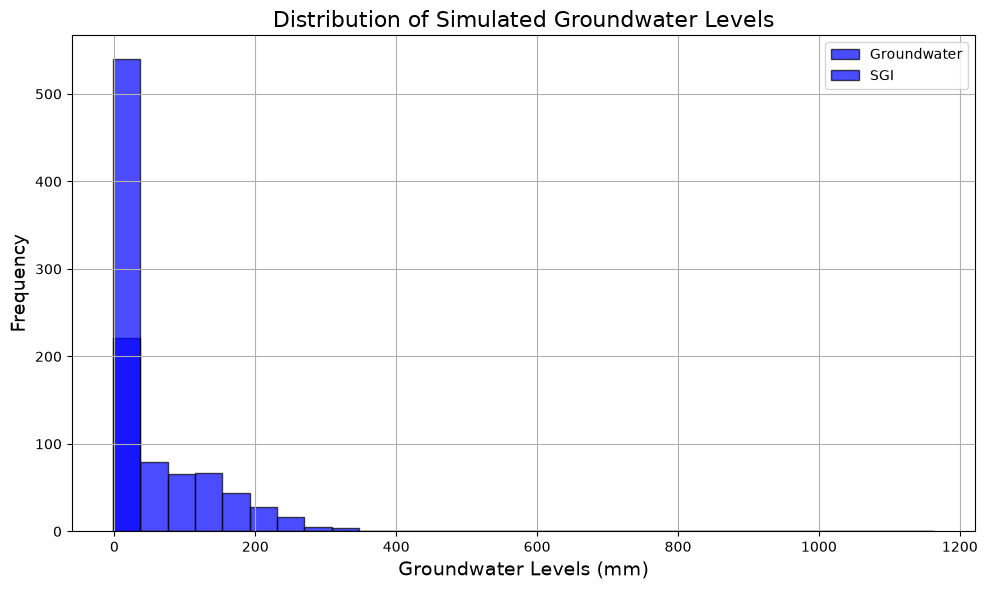

In [30]:
# Plotting the distribution of simulated groundwater levels
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
gw_sim.plot(kind="hist", bins=30, ax=ax, alpha=0.7, color="blue", edgecolor="black")

# Adding plot labels
ax.set_title("Distribution of Simulated Groundwater Levels", fontsize=16)
ax.set_xlabel("Groundwater Levels (mm)", fontsize=14)
ax.set_ylabel("Frequency", fontsize=14)
ax.grid(True)

plt.tight_layout()
plt.savefig(plot_dir / "Groundwater_Distribution_Simulated.svg")
plt.show()
plt.close()

In [31]:
# normalising the groundwater
gw_sim_norm = (gw_sim["Groundwater"] - gw_sim["Groundwater"].mean()) / gw_sim["Groundwater"].std()
gw_norm = (gw["GW levels (mAOD)"] - gw["GW levels (mAOD)"].mean()) / gw["GW levels (mAOD)"].std()

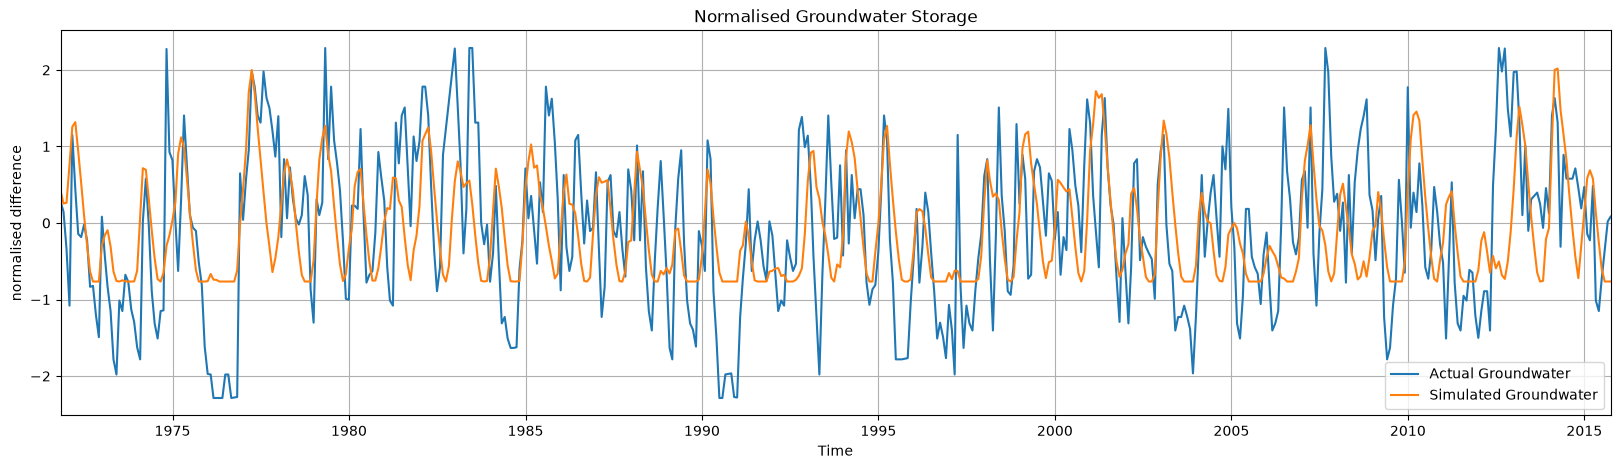

In [32]:
# plotting the groundwater
fig, ax = plt.subplots(1, 1, figsize=(20, 5))

# Determining the bounds
start_date = max(gw_sim_norm.index.min(), gw_norm.index.min()) + pd.DateOffset(years=1)
end_date = min(gw_sim_norm.index.max(), gw_norm.index.max())

ax.plot(gw_norm.loc[start_date:end_date], label="Actual Groundwater")
ax.plot(gw_sim_norm.loc[start_date:end_date], label="Simulated Groundwater")

ax.set_xlabel("Time")
ax.set_ylabel("normalised difference")
ax.set_title("Normalised Groundwater Storage")
ax.set_xlim([start_date, end_date])
ax.grid()
ax.legend()
plt.savefig(plot_dir / "Groundwater_Storage.svg")
plt.show()
plt.close()

In [33]:
# error of the groundwater model
gw_norm_period = gw_norm.loc[start_date:end_date]
gw_sim_norm_period = gw_sim_norm.loc[start_date:end_date]

# Align the indices of the two dataframes
aligned_gw_norm, aligned_gw_sim_norm = gw_norm_period.align(gw_sim_norm_period, join="inner")

error_gw = least_squares(aligned_gw_norm.values, aligned_gw_sim_norm.values)
print(f"Error of the groundwater model (Least Squares): {error_gw}")

Error of the groundwater model (Least Squares): 460.6401053217802


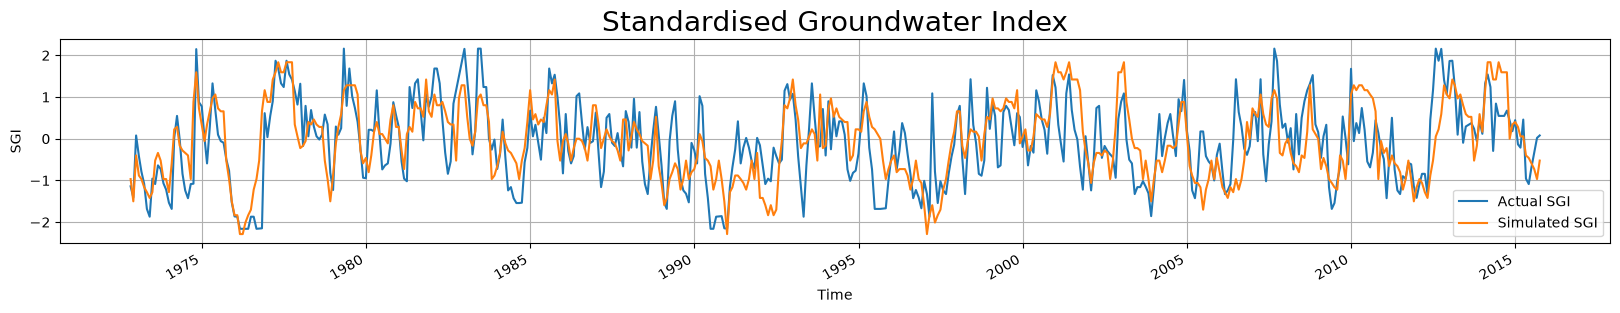

In [34]:
# plotting the SGI values

fig, ax = plt.subplots(1, 1, figsize=(20, 3))

start_date = max(gw_sim_norm_period.index.min(), gw_norm_period.index.min()) + pd.DateOffset(
    years=1
)
end_date = min(gw_sim_norm_period.index.max(), gw_norm_period.index.max())

gw["sgi"].loc[start_date:end_date].plot(ax=ax, label="Actual SGI")
gw_sim["SGI"].loc[start_date:end_date].plot(ax=ax, label="Simulated SGI")

ax.set_xlabel("Time")
ax.set_ylabel("SGI")
ax.set_title("Standardised Groundwater Index", fontsize=20)
ax.grid()
ax.legend()
plt.savefig(plot_dir / "SGI.svg")
plt.show()
plt.close()

In [35]:
# Align the indices of the two dataframes
aligned_gw_sgi, aligned_gw_sim_sgi = (
    gw["sgi"].loc[start_date:end_date].align(gw_sim["SGI"].loc[start_date:end_date], join="inner")
)

# error of the SGI model
error_sgi = least_squares(aligned_gw_sgi.values, aligned_gw_sim_sgi.values)
print(f"Error of the SGI model (Least Squares): {error_sgi}")

Error of the SGI model (Least Squares): 286.7759928719711


## 5. Reservoir storage: Waitt calculation

The abstraction allowance is 2% of river discharge. Domestic demand is
142 litres per person per day for 150,000 people: **21,300 m³/day**, rather
than per month as stated in the report. Monthly demand is aggregated from daily values.

The Waitt calculation pairs the rolling sum for `i` months with cumulative
demand for `i + 1` months and includes a zero-month window. This mismatch affects
the calculated reservoir capacity. The reported 55 months is a critical-period
index, not a return period.


In [36]:
# Domestic water demand in m³/day.
population = 150_000
demand_litres_per_person = 142
daily_demand = (demand_litres_per_person / 1000) * population

In [37]:
# calculating the flow and draft
abstraction = 0.02  # 2% of river discharge, as specified in the brief
flow = hydrometeorology["discharge_vol"] * 24 * 3600 * abstraction
hydrometeorology["demand"] = daily_demand
draft = flow - daily_demand
cum_flow = flow.cumsum()
cum_demand = pd.Series(daily_demand, index=flow.index).cumsum()
cum_draft = cum_demand - cum_flow

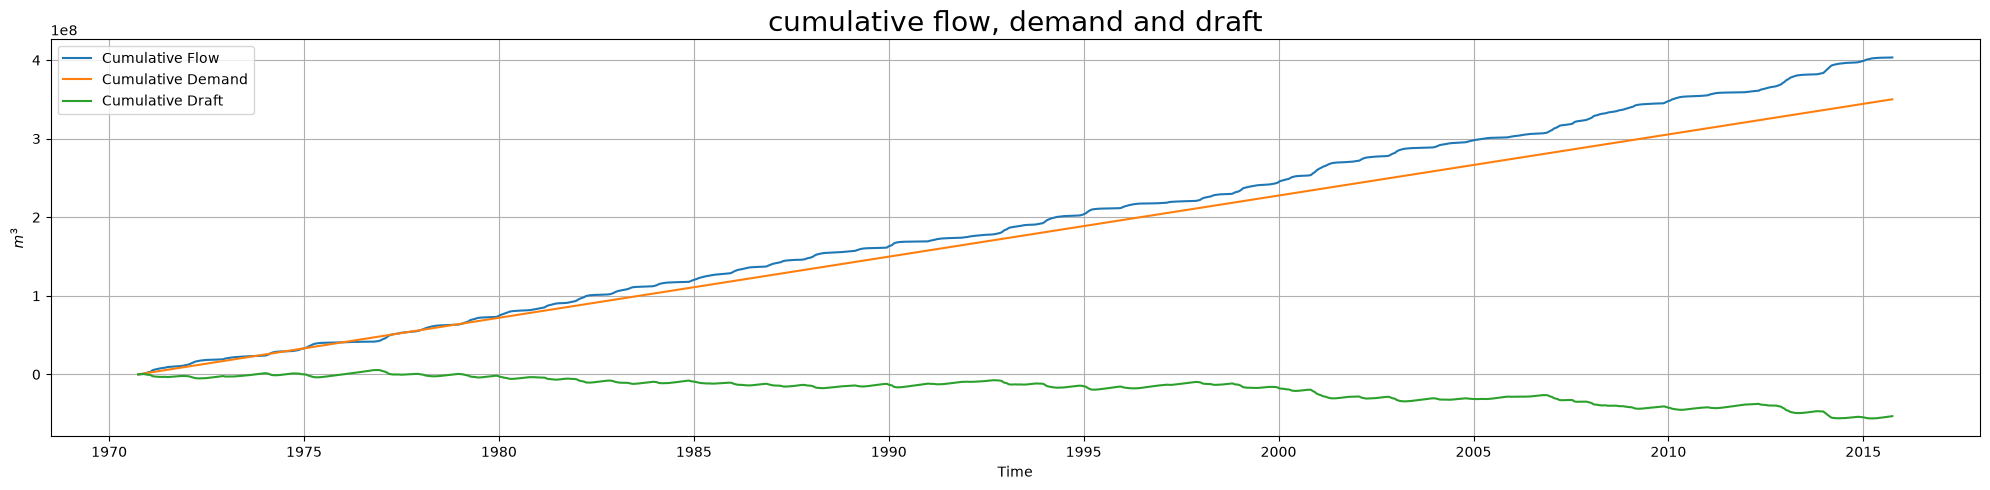

In [38]:
# plotting the flow, demand and draft
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
ax.plot(cum_flow, label="Cumulative Flow")
ax.plot(cum_demand, label="Cumulative Demand")
ax.plot(cum_draft, label="Cumulative Draft")

ax.set_xlabel("Time")
ax.set_ylabel(r"$m^3$")
ax.set_title("cumulative flow, demand and draft", fontsize=20)
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig(plot_dir / "Cumulative_Flow_Demand_Draft.svg")
plt.show()
plt.close()

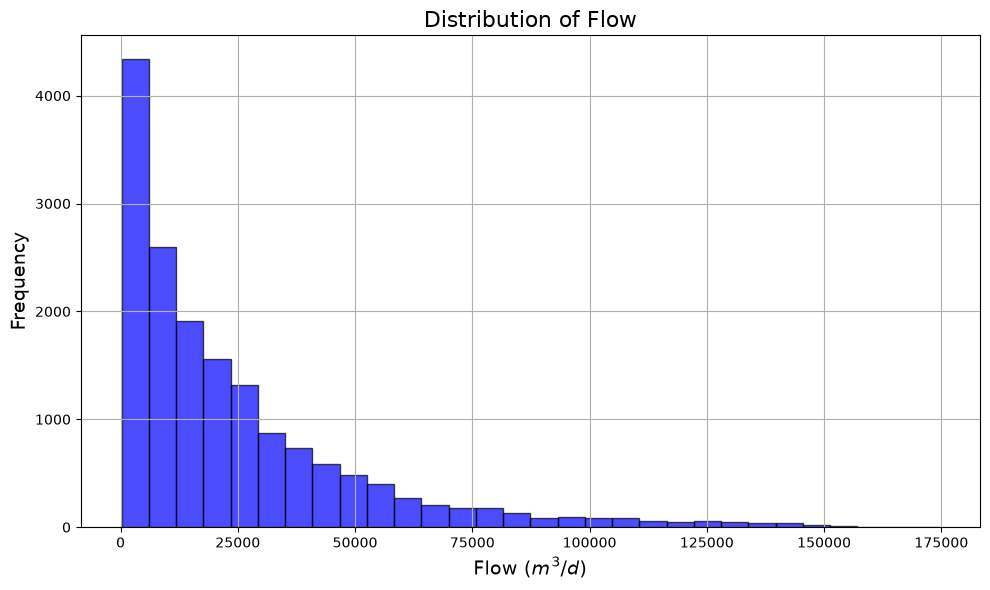

In [39]:
# flow distribution plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
flow.plot(kind="hist", bins=30, ax=ax, alpha=0.7, color="blue", edgecolor="black")

# Adding plot labels
ax.set_title("Distribution of Flow", fontsize=16)
ax.set_xlabel("Flow ($m^3/d$)", fontsize=14)
ax.set_ylabel("Frequency", fontsize=14)
ax.grid(True)

plt.tight_layout()
plt.savefig(plot_dir / "Flow_Distribution.svg")
plt.show()
plt.close()

In [40]:
# applying the waitt method for reservoir design
monthly_flow = hydrometeorology["discharge_vol"].resample("ME").sum() * 24 * 3600 * abstraction
monthly_demand = hydrometeorology["demand"].resample("ME").sum().reset_index(drop=True)
monthly_cum_demand = monthly_demand.cumsum()
waitt = np.zeros(len(monthly_flow))

for i in range(0, len(monthly_flow)):
    waitt[i] = monthly_flow.rolling(i).sum().dropna().min()


# calculating the difference
difference = monthly_cum_demand - waitt
reservoir_size = difference.max()
location = difference.idxmax()
print(
    f"The reservoir size required is {reservoir_size} m^3 and the critical-period index is {location} months"
)

The reservoir size required is 11264480.639999993 m^3 and the critical-period index is 55 months


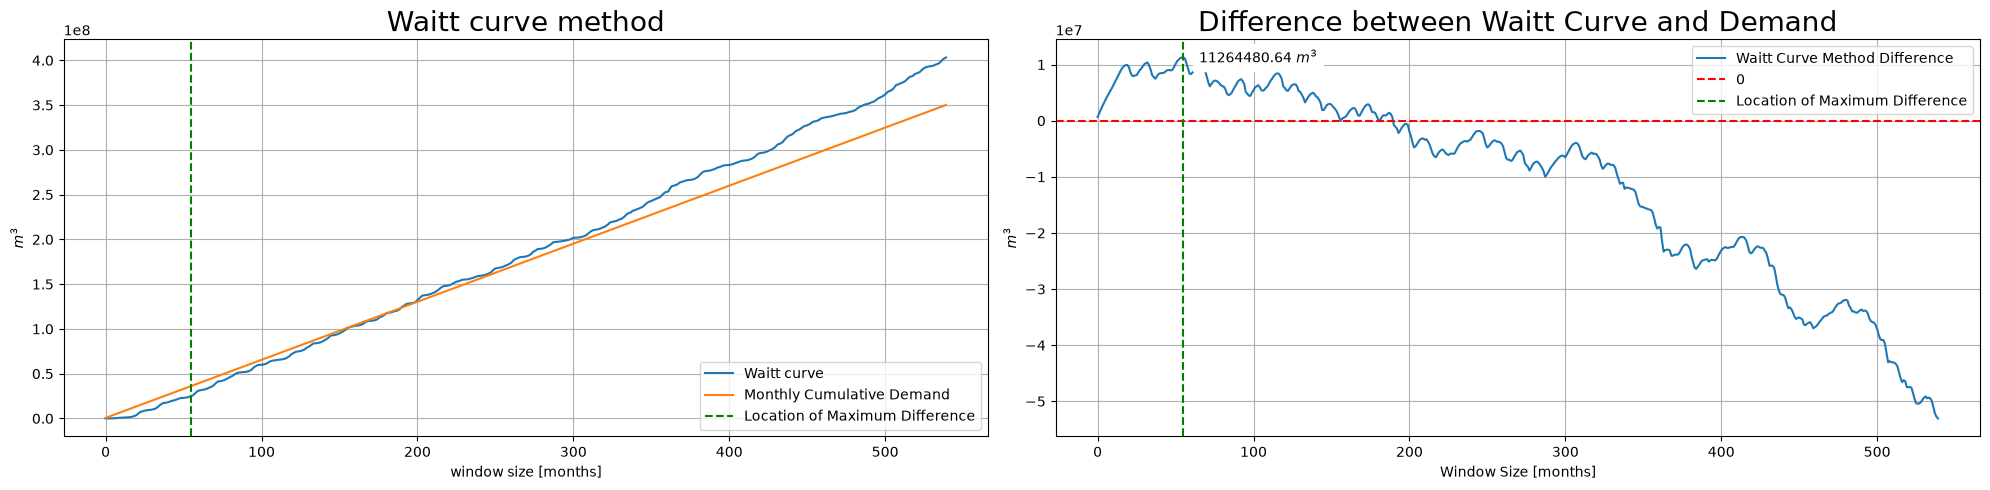

In [41]:
# plotting the waitt method
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
ax[0].plot(waitt, label="Waitt curve")
ax[0].plot(monthly_cum_demand, label="Monthly Cumulative Demand")
ax[0].axvline(location, color="g", linestyle="--", label="Location of Maximum Difference")

ax[0].set_xlabel("window size [months]")
ax[0].set_ylabel(r"$m^3$")
ax[0].set_title("Waitt curve method", fontsize=20)
ax[0].grid(True)
ax[0].legend()

# plotting the difference between the waitt method and the demand
ax[1].plot(monthly_cum_demand - waitt, label="Waitt Curve Method Difference")
ax[1].axhline(0, color="r", linestyle="--", label="0")
ax[1].axvline(location, color="g", linestyle="--", label="Location of Maximum Difference")
ax[1].text(
    location + 10,
    difference.max(),
    f"{difference.max():.2f} $m^3$",
    fontsize=10,
    verticalalignment="center",
    horizontalalignment="left",
    backgroundcolor="white",
)

ax[1].set_xlabel("Window Size [months]")
ax[1].set_ylabel(r"$m^3$")
ax[1].set_title("Difference between Waitt Curve and Demand", fontsize=20)
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.savefig(plot_dir / "Waitt_Method.svg")
plt.show()
plt.close()